## 1. Setup and Imports
Importing libraries for data handling, visualization, and modelling.
Random seed is fixed to 42 for reproducible results.

In [1]:
# Setup and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# helper: RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

sns.set_style("whitegrid")

RANDOM_STATE = 42

## 2. Load the Dataset
Loaded from the local ENB2012_data.xlsx file with pandas (read_excel).
Target selected is Heating Load (Y1); Cooling Load (Y2) is not used as a predictor.

In [2]:
# Load the Energy Efficiency dataset
df_raw = pd.read_excel("ENB2012_data.xlsx")

print(df_raw.shape)
df_raw.head()

(768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 3. Preprocessing

Removed X6 (Orientation) and X8 (Glazing Area Distribution): although stored as integers, 
they are categorical-like codes with no meaningful numeric order or scale, so treating them 
as quantitative predictors in a linear regression would be invalid.

In [ ]:
# Step 5 — Preprocessing
# Drop qualitative
df = df_raw.drop(columns=["X6", "X8"]).copy()

# Keep only Heating Load (Y1) as target; drop Cooling Load (Y2)
if "Y2" in df.columns:
    df = df.drop(columns=["Y2"])

# Check shape, data types, and missing values
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

df.head()

Shape: (768, 7)

Data types:
 X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X7    float64
Y1    float64
dtype: object

Missing values:
 X1    0
X2    0
X3    0
X4    0
X5    0
X7    0
Y1    0
dtype: int64


,X1,X2,X3,X4,X5,X7,Y1
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55
3,0.98,514.5,294.0,110.25,7.0,0.0,15.55
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84


### EDA

In [ ]:
# EDA setup
TARGET = "Y1"
predictors = ["X1", "X2", "X3", "X4", "X5", "X7"]

# readable names for charts
nice_names = {
    "X1": "Relative Compactness",
    "X2": "Surface Area",
    "X3": "Wall Area",
    "X4": "Roof Area",
    "X5": "Overall Height",
    "X7": "Glazing Area",
    "Y1": "Heating Load",
}

### Univariate — Distributions (KDE plots)
**New chart type #1: KDE (density) plots.** Used instead of histograms because a smooth 
density curve shows the shape of each distribution — skew, and whether a variable is 
bimodal — without depending on bin choices.

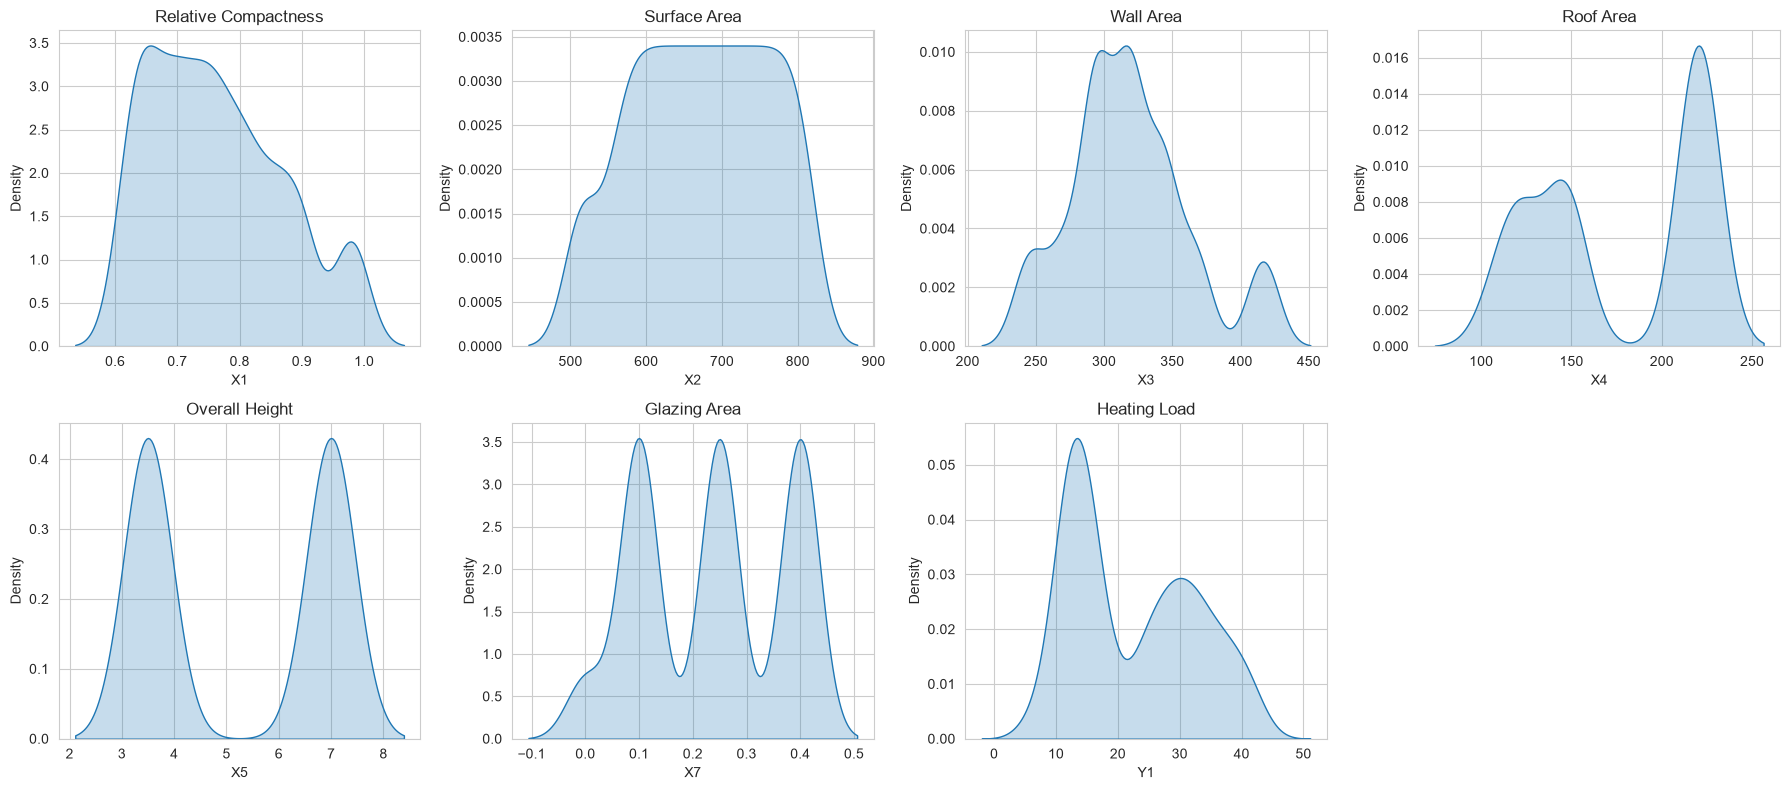

In [ ]:
# Univariate: KDE (density) plots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, predictors + [TARGET]):
    sns.kdeplot(data=df, x=col, fill=True, ax=ax)
    ax.set_title(nice_names[col])
# hide the last empty subplot
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

### Univariate — Spread & Outliers (violin plots)
**New chart type #2: violin plots.** Used instead of boxplots because a violin shows the 
full distribution shape *and* the quartiles/outliers in one view, revealing where values 
cluster.

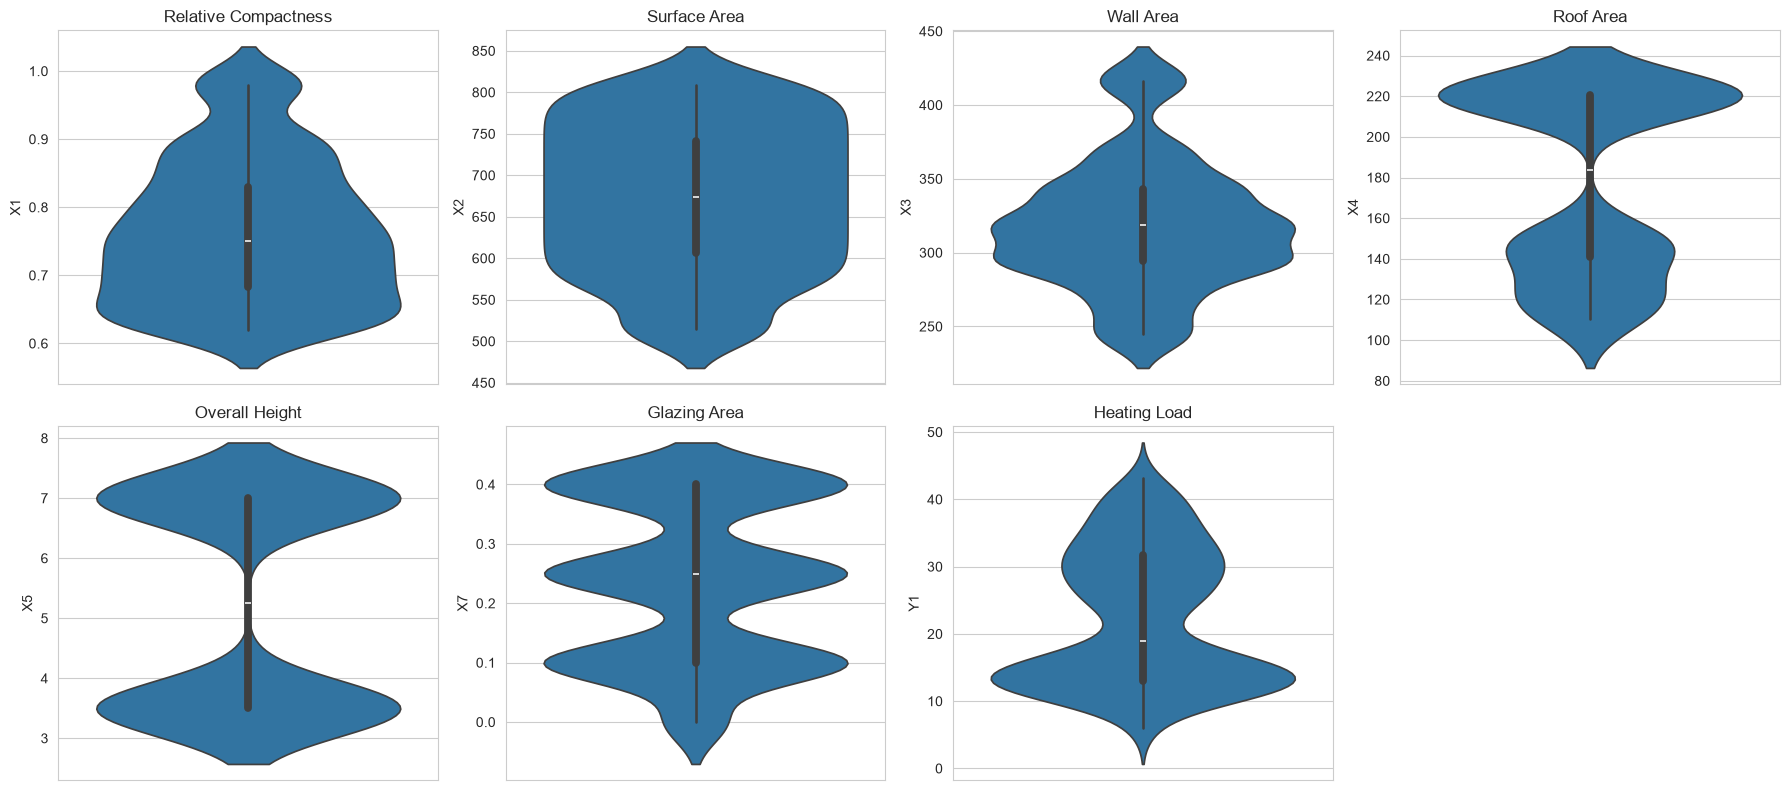

Skewness:
 X3    0.533417
X1    0.495513
Y1    0.360446
X5    0.000000
X7   -0.060254
X2   -0.125131
X4   -0.162764
dtype: float64


In [ ]:
# Univariate: violin plots for spread & outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, predictors + [TARGET]):
    sns.violinplot(y=df[col], ax=ax)
    ax.set_title(nice_names[col])
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

# skewness numbers to back up what the charts show
print("Skewness:\n", df[predictors + [TARGET]].skew().sort_values(ascending=False))

### Bivariate — Predictors vs Heating Load
Regression plots (scatter + fitted line) are appropriate here because they show both the 
direction and the shape (linear vs curved) of each predictor's relationship with the target.

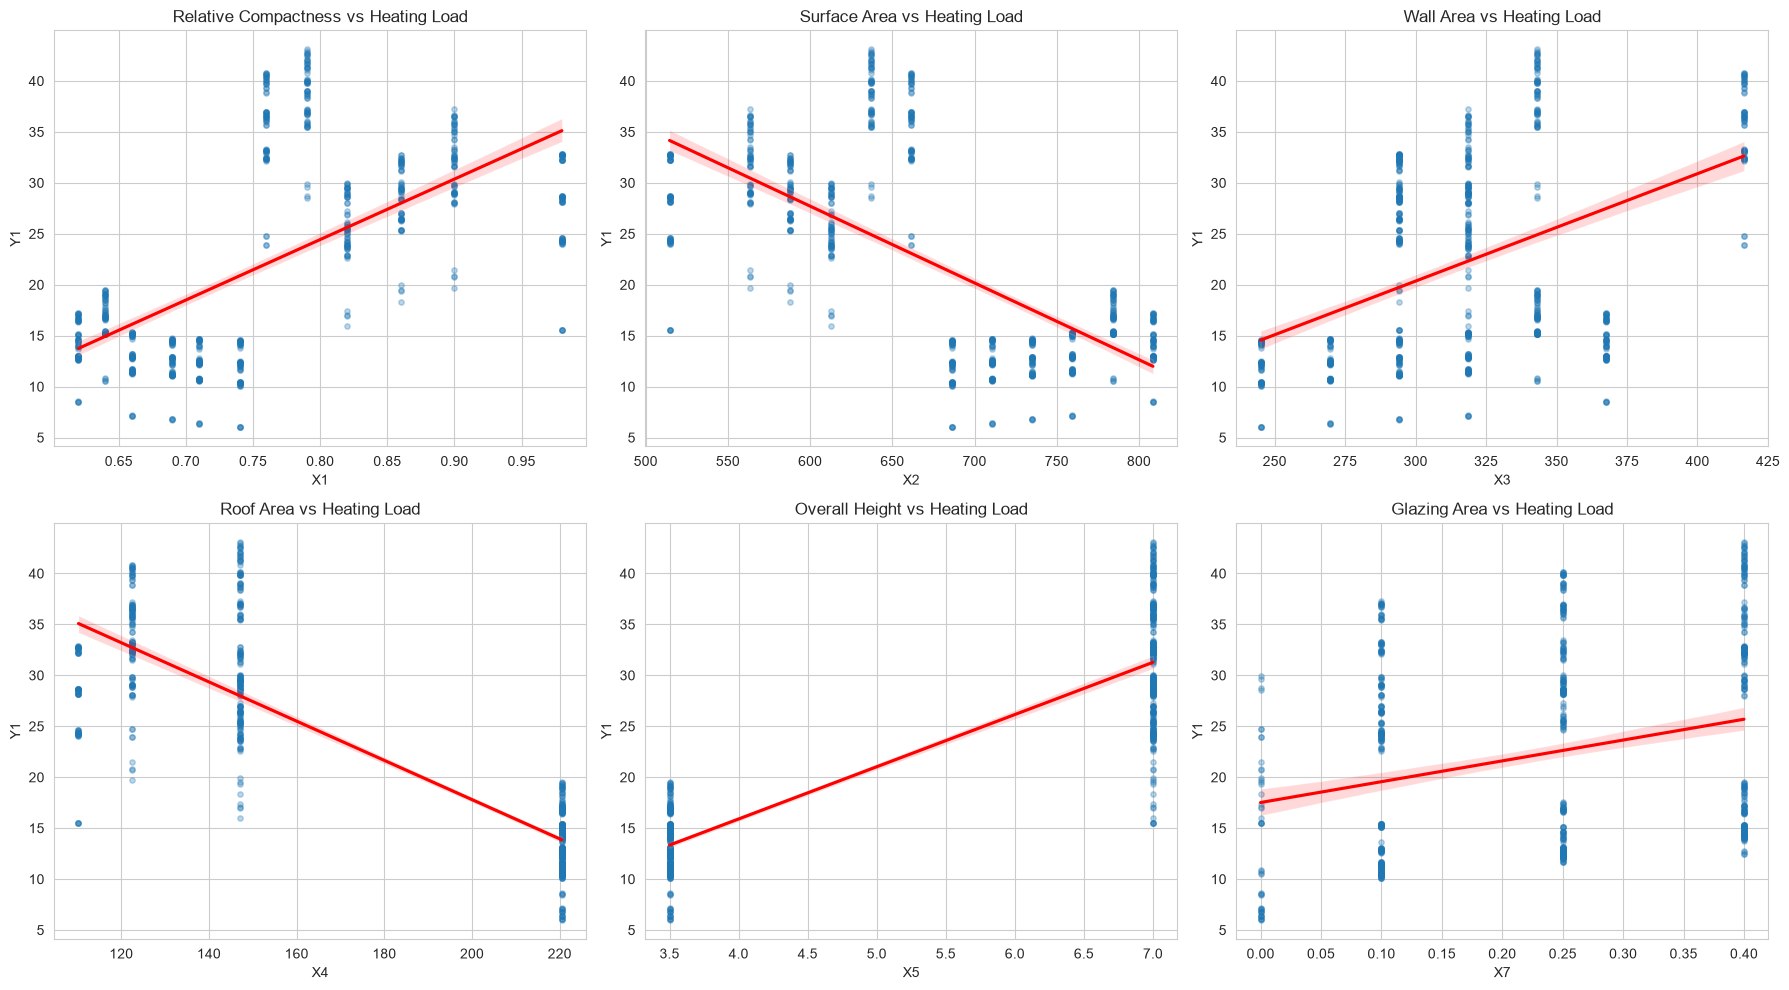

In [ ]:
# Bivariate: each predictor vs Heating Load (regression plots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, predictors):
    sns.regplot(data=df, x=col, y=TARGET, ax=ax,
                scatter_kws={"alpha": 0.3, "s": 15},
                line_kws={"color": "red"})
    ax.set_title(f"{nice_names[col]} vs Heating Load")
plt.tight_layout()
plt.show()

### Correlation Analysis (clustermap)
** clustermap ** Chosen over a plain heatmap because it reorders variables 
so that mutually correlated predictors sit together, making collinearity easy to spot at a 
glance. The sorted table quantifies each predictor's linear association with Heating Load.

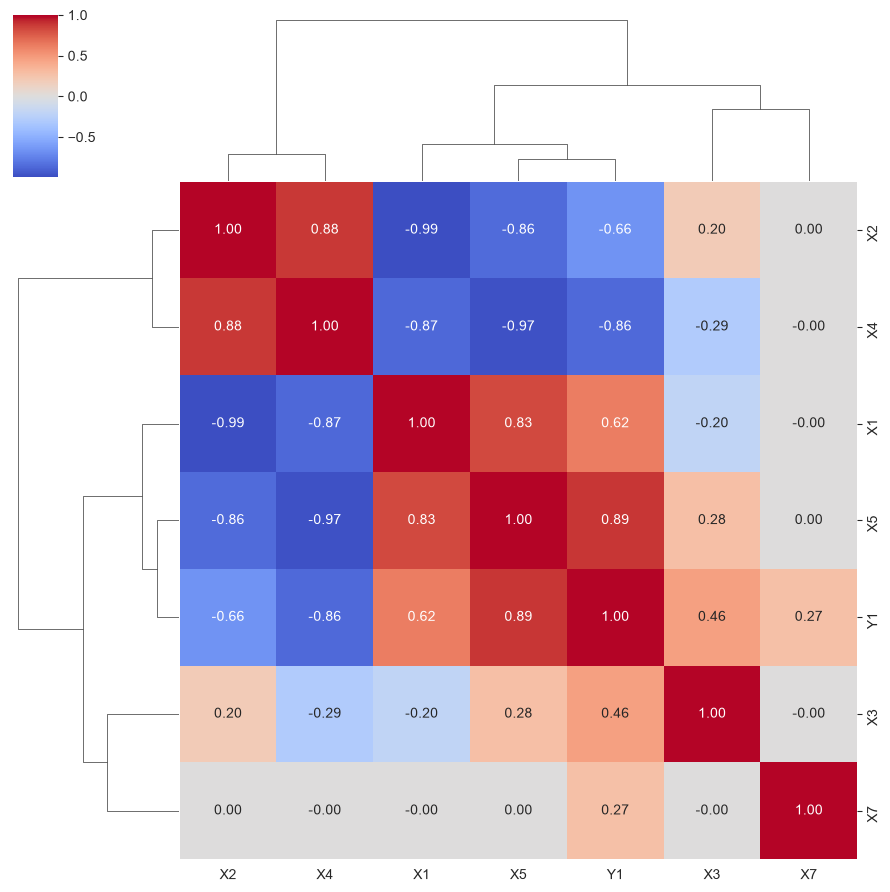

Correlation with Heating Load (Y1):
 X5    0.889430
X1    0.622272
X3    0.455671
X7    0.269842
X2   -0.658120
X4   -0.861828
Name: Y1, dtype: float64


In [10]:
# Correlation: clustermap  [NEW CHART TYPE #3 — groups collinear predictors]
corr = df[predictors + [TARGET]].corr()

sns.clustermap(corr, annot=True, cmap="coolwarm", center=0,
               fmt=".2f", figsize=(9, 9))
plt.show()

# correlation of each predictor with the target, sorted
print("Correlation with Heating Load (Y1):\n",
      corr[TARGET].drop(TARGET).sort_values(ascending=False))